In [1]:
import sys
from pathlib import Path
import os

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))
os.chdir(Path.cwd().parent)
from src.utils.config import load_config
from src.models.train_model import get_models, evaluate
from sklearn.model_selection import train_test_split

config = load_config()
model_cfg = config['model']

In [2]:
df = pd.read_csv(config['data']['processed_path'])
target_col = model_cfg['target_column']
feature_cols = [c for c in df.columns if c not in [target_col, 'customer_id']]

X = df[feature_cols]
y = df[target_col]
print(f'{X.shape[1]} features, {len(y)} samples, churn rate = {y.mean():.2%}')

19 features, 5000 samples, churn rate = 36.48%


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=model_cfg['test_size'],
    random_state=model_cfg['random_state'],
    stratify=y,
)
print(X_train.shape, X_test.shape)

(4000, 19) (1000, 19)


In [4]:
models = get_models(model_cfg['random_state'])
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    metrics = evaluate(model, X_test, y_test)
    results[name] = metrics
    print(f'{name:20s} -> {metrics}')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


logistic_regression  -> {'accuracy': 0.797, 'precision': 0.720108695652174, 'recall': 0.726027397260274, 'f1': 0.723055934515689, 'roc_auc': 0.8704864631647071}


random_forest        -> {'accuracy': 0.796, 'precision': 0.713527851458886, 'recall': 0.736986301369863, 'f1': 0.7250673854447439, 'roc_auc': 0.8732261891921044}


xgboost              -> {'accuracy': 0.798, 'precision': 0.7270194986072424, 'recall': 0.7150684931506849, 'f1': 0.7209944751381215, 'roc_auc': 0.8685406105058786}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


voting_ensemble      -> {'accuracy': 0.8, 'precision': 0.7298050139275766, 'recall': 0.7178082191780822, 'f1': 0.7237569060773481, 'roc_auc': 0.8767382159421853}


In [5]:
results_df = pd.DataFrame(results).T.sort_values('f1', ascending=False)
results_df

,accuracy,precision,recall,f1,roc_auc
random_forest,0.796,0.713528,0.736986,0.725067,0.873226
voting_ensemble,0.800,0.729805,0.717808,0.723757,0.876738
logistic_regression,0.797,0.720109,0.726027,0.723056,0.870486
xgboost,0.798,0.727019,0.715068,0.720994,0.868541


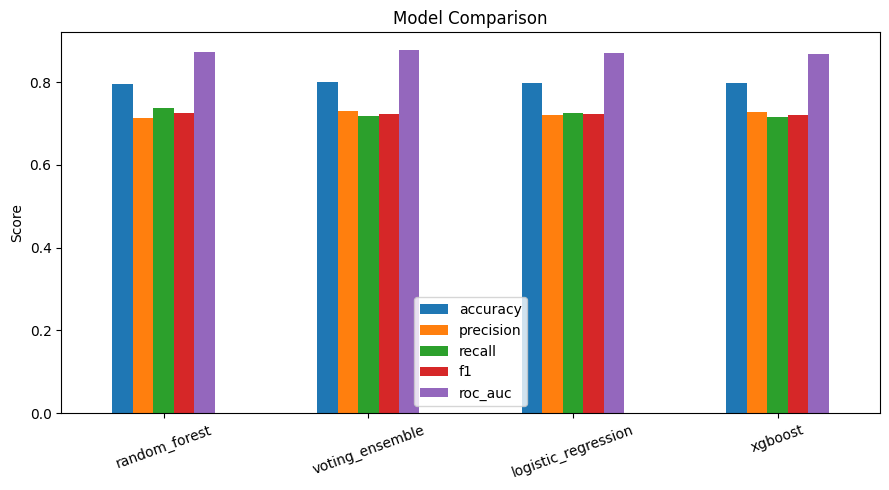

In [6]:
results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].plot(
    kind='bar', figsize=(9, 5), title='Model Comparison'
)
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [7]:
best_name = results_df['f1'].idxmax()
best_model = models[best_name]
print(f'Best model: {best_name} (F1={results_df.loc[best_name, "f1"]:.4f})')

Best model: random_forest (F1=0.7251)


In [8]:
import joblib

saved_model_path = Path(model_cfg['saved_model_path'])
saved_model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({'model': best_model, 'features': feature_cols, 'name': best_name}, saved_model_path)
print(f'Saved -> {saved_model_path}')

Saved -> models/saved_models/churn_model.pkl
